# Crawl data

In [ ]:
import requests
import time
import random
import pandas as pd
from tqdm import tqdm

In [ ]:
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/116.0.0.0 Safari/537.36',
    'Accept': 'application/json, text/plain, */*',
    'Accept-Language': 'vi-VN,vi;q=0.9,fr-FR;q=0.8,fr;q=0.7,en-US;q=0.6,en;q=0.5',
    'Referer': 'https://tiki.vn/dien-thoai-may-tinh-bang/c1789?fbclid=IwAR3AKJszxaRdBfMAZ6DEUkkq9F-Ws6PmRnjZcsu-X3aqSAlwA8G9GfTAH4A',
    'x-guest-token': '3zw7jkMYAZmgK2LcGQbNhvHPs6SB5ndI',
    'Connection': 'keep-alive',
    'TE': 'Trailers',
}

params = {
    'limit': '40', # mỗi page hiện tối đa 40 sản phẩm
    'include': 'advertisement',
    'aggregations': '2',
    'trackity_id': '28c41b25-1dc5-d482-9316-985231abd1e6',
    'category': '1789',
    'page': '1',
    'src': 'c1789',
    'urlKey':  'dien-thoai-may-tinh-bang',
}
product_id = []
for i in range(1, 28): # quét tối đa 27 trang để lấy id sản phẩm

    params['page'] = i
    response = requests.get('https://tiki.vn/api/personalish/v1/blocks/listings', headers=headers, params=params)
    if response.status_code == 200:
        print('request success!!!')
        for record in response.json().get('data'):
            product_id.append({'id': record.get('id')})
    time.sleep(random.randrange(1, 3))

df = pd.DataFrame(product_id)
df.to_csv('product_id_ncds.csv', index=False)

request success!!!
request success!!!
request success!!!
request success!!!
request success!!!
request success!!!
request success!!!
request success!!!
request success!!!
request success!!!
request success!!!
request success!!!
request success!!!
request success!!!
request success!!!
request success!!!
request success!!!
request success!!!
request success!!!
request success!!!
request success!!!
request success!!!
request success!!!
request success!!!
request success!!!
request success!!!
request success!!!


In [ ]:
df


,id
0,247730209
1,250109584
2,194034217
3,259542697
4,216174231
...,...
1052,271954384
1053,271392661
1054,271163328
1055,271329051


In [ ]:
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/116.0.0.0 Safari/537.36',
    'Accept': 'application/json, text/plain, */*',
    'Accept-Language': 'vi-VN,vi;q=0.9,fr-FR;q=0.8,fr;q=0.7,en-US;q=0.6,en;q=0.5',
    'Referer': 'https://tiki.vn/dien-thoai-samsung-galaxy-a34-5g-8gb-128gb-hang-chinh-hang-p247730209.html?',
    'x-guest-token': '3zw7jkMYAZmgK2LcGQbNhvHPs6SB5ndI',
    'Connection': 'keep-alive',
    'TE': 'Trailers',
}

params = {
    'product_id': '247730209',
    'sort': 'score|desc,id|desc,stars|all',
    'page': '1',
    'limit': '12',
    'include': 'comments,contribute_info,attribute_vote_summary'
}

def comment_parser(json):
    d = dict()
    d['id'] = json.get('id')
    d['content'] = json.get('content')
    d['rating'] = json.get('rating')
    return d


df_id = pd.read_csv('product_id_ncds.csv')
p_ids = df_id.id.to_list()
result = []
for pid in tqdm(p_ids, total=len(p_ids)):
    params['product_id'] = pid
    print('Crawl comment for product {}'.format(pid))
    for i in range(1,3):
        params['page'] = i
        response = requests.get('https://tiki.vn/api/v2/reviews', headers=headers, params=params)
        if response.status_code == 200:
            print('Crawl comment page {} success!!!'.format(i))
            for comment in response.json().get('data'):
                result.append(comment_parser(comment))
df_comment = pd.DataFrame(result)
df_comment.to_csv('comments_data_ncds.csv', index=False)

  0%|          | 0/1057 [00:00<?, ?it/s]

Crawl comment for product 247730209
Crawl comment page 1 success!!!


  0%|          | 1/1057 [00:00<15:32,  1.13it/s]

Crawl comment page 2 success!!!
Crawl comment for product 250109584
Crawl comment page 1 success!!!


  0%|          | 2/1057 [00:04<43:51,  2.49s/it]

...

Crawl comment page 2 success!!!
Crawl comment for product 271329051
Crawl comment page 1 success!!!


100%|█████████▉| 1056/1057 [15:05<00:00,  1.44it/s]

Crawl comment page 2 success!!!
Crawl comment for product 271164165
Crawl comment page 1 success!!!


100%|██████████| 1057/1057 [15:06<00:00,  1.17it/s]

Crawl comment page 2 success!!!


In [ ]:
df_comment

,id,content,rating
0,19531204,"Mình đã nhận được điện thoại, hàng còn nguyên ...",5
1,19082694,"Camera cũng tạm, đủ sáng thì ok, camera trước ...",5
2,19120490,"Mua lần nào cũng hài lòng , đặt hôm trước thì ...",5
3,19508169,"Đúng nguyen seal, giao hàng nhanh lịch sự, rất...",5
4,19180405,Ủa mà dòng này không có sẵn sạc kèm theo trong...,2
...,...,...,...
5160,3556989,Dùng ok. Pin khoẻ. Rất nên mua,5
5161,3809358,,5
5162,19189373,Rất tốt! Trang trí đẹp như trong phim Hồng Kong!,5
5163,7453082,Không dùng được sim di động là sao,1


# Tiền xử lý

In [1]:
import numpy as np
import pandas as pd
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
import gensim

In [2]:
df = pd.read_csv('/content/drive/MyDrive/comments_data_ncds.csv')
print(df.head(30).to_string(index = False))

      id                                                                                                                                                                                                                                                                                                                                             content  rating
19531204 Mình đã nhận được điện thoại, hàng còn nguyên đai nguyên kiện, rất đẹp và kiểm tra là chính hãng. nhưng lúc mua mình định mua trả gop mà lúc thanh toán online thì mình lại bấm thanh toán toàn bộ, nay hàng về mới thấy giá chênh lệch 205k. đề nghị nhà bán kiểm tra giúp giao dịch và chuyển lại tiền cho mình số thừa so với giá bán với nhé ạ.       5
19082694                                                                                                                                                                                             Camera cũng tạm, đủ sáng thì ok, camera trước chụp vô như bệnh gan 😇\r\nĐiện thoại dùng m

In [3]:
df

,id,content,rating
0,19531204,"Mình đã nhận được điện thoại, hàng còn nguyên ...",5
1,19082694,"Camera cũng tạm, đủ sáng thì ok, camera trước ...",5
2,19120490,"Mua lần nào cũng hài lòng , đặt hôm trước thì ...",5
3,19508169,"Đúng nguyen seal, giao hàng nhanh lịch sự, rất...",5
4,19180405,Ủa mà dòng này không có sẵn sạc kèm theo trong...,2
...,...,...,...
5160,3556989,Dùng ok. Pin khoẻ. Rất nên mua,5
5161,3809358,NaN,5
5162,19189373,Rất tốt! Trang trí đẹp như trong phim Hồng Kong!,5
5163,7453082,Không dùng được sim di động là sao,1


In [4]:
df.isna().sum()

id            0
content    1777
rating        0
dtype: int64

In [5]:
#xử lý dữ liệu bị thiếu
df.dropna(inplace = True)

In [6]:
df

,id,content,rating
0,19531204,"Mình đã nhận được điện thoại, hàng còn nguyên ...",5
1,19082694,"Camera cũng tạm, đủ sáng thì ok, camera trước ...",5
2,19120490,"Mua lần nào cũng hài lòng , đặt hôm trước thì ...",5
3,19508169,"Đúng nguyen seal, giao hàng nhanh lịch sự, rất...",5
4,19180405,Ủa mà dòng này không có sẵn sạc kèm theo trong...,2
...,...,...,...
5155,5413301,Good deal. Thank you Tiki,5
5159,5543702,good,5
5160,3556989,Dùng ok. Pin khoẻ. Rất nên mua,5
5162,19189373,Rất tốt! Trang trí đẹp như trong phim Hồng Kong!,5


In [7]:
df.to_csv('clean_content.csv', index=False)

In [8]:
df = pd.read_csv('/content/drive/MyDrive/clean_content.csv')
df

,id,content,rating
0,19531204,"Mình đã nhận được điện thoại, hàng còn nguyên ...",5
1,19082694,"Camera cũng tạm, đủ sáng thì ok, camera trước ...",5
2,19120490,"Mua lần nào cũng hài lòng , đặt hôm trước thì ...",5
3,19508169,"Đúng nguyen seal, giao hàng nhanh lịch sự, rất...",5
4,19180405,Ủa mà dòng này không có sẵn sạc kèm theo trong...,2
...,...,...,...
3383,5413301,Good deal. Thank you Tiki,5
3384,5543702,good,5
3385,3556989,Dùng ok. Pin khoẻ. Rất nên mua,5
3386,19189373,Rất tốt! Trang trí đẹp như trong phim Hồng Kong!,5


Text(0.5, 1.0, 'Biểu đồ biểu diễn số lượng của từng loại rating')

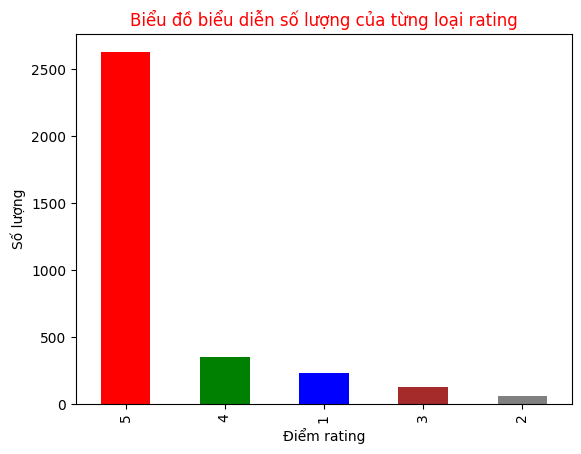

In [9]:
df.rating.value_counts().plot(kind='bar', color = ['red', 'green', 'blue', 'brown', 'gray'])
plt.xlabel("Điểm rating")
plt.ylabel("Số lượng")
plt.title("Biểu đồ biểu diễn số lượng của từng loại rating", color = 'r')

In [10]:
#rating trung bình của sản phẩm
rating_sum = 0
for i in df['rating']:
  rating_sum = rating_sum + i
rating_tb = rating_sum/len(df['rating'])
rating_tb

4.5005903187721366

In [11]:
#Gán nhãn cho bộ  dữ liệu
sentiment = []
for i in df['rating']:
  if i > 4:
    sentiment.append('positive')
  elif i < 4:
    sentiment.append('negative')
  else:
    sentiment.append('neutral')

In [12]:
df['sentiment'] = sentiment
df.head(30)

,id,content,rating,sentiment
0,19531204,"Mình đã nhận được điện thoại, hàng còn nguyên ...",5,positive
1,19082694,"Camera cũng tạm, đủ sáng thì ok, camera trước ...",5,positive
2,19120490,"Mua lần nào cũng hài lòng , đặt hôm trước thì ...",5,positive
3,19508169,"Đúng nguyen seal, giao hàng nhanh lịch sự, rất...",5,positive
4,19180405,Ủa mà dòng này không có sẵn sạc kèm theo trong...,2,negative
5,19211217,Nguyên seal,5,positive
6,19154234,OK lem,5,positive
7,19279062,"Đóng gói đẹp, Máy nguyên hộp, chưa xử dụng, đú...",5,positive
8,19313410,"Mua gửi cho con trai ở xa, nên không nhìn được...",5,positive
9,19508849,"Mẫu mã đẹp nhung sai không ngon, chi nghe gọi ...",1,negative


Text(0.5, 1.0, 'Biểu đồ biểu diễn số lượng của từng loại cảm xúc của dữ liệu')

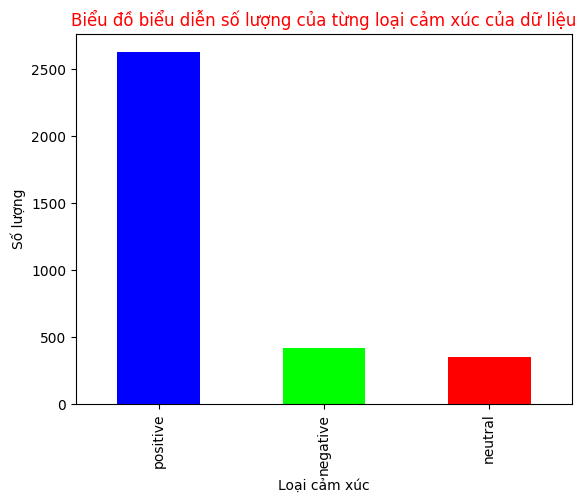

In [13]:
df.sentiment.value_counts().plot(kind='bar',color=['blue','lime','red'])
plt.xlabel("Loại cảm xúc")
plt.ylabel("Số lượng")
plt.title("Biểu đồ biểu diễn số lượng của từng loại cảm xúc của dữ liệu", color = 'r')

<Axes: ylabel='sentiment'>

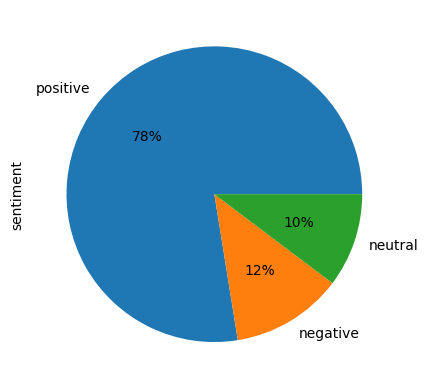

In [14]:
df.sentiment.value_counts().plot(kind='pie', autopct='%1.0f%%')

In [15]:
!pip install pyvi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 49.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 993.5/993.5 kB 62.6 MB/s eta 0:00:00


In [16]:
#đưa các chữ thành chữ thường, xóa các ký tự đặc biệt, tách từ
from pyvi import ViTokenizer
text = []
for i in df['content']:
    lines = gensim.utils.simple_preprocess(str(i))
    lines = ' '.join(lines)
    lines = ViTokenizer.tokenize(lines)
    text.append(lines)

In [17]:
text#[:10]

['mình đã nhận được điện_thoại hàng còn nguyên đai nguyên kiện rất đẹp và kiểm_tra là chính hãng nhưng lúc mua mình định mua trả gop mà lúc thanh_toán online thì mình lại bấm thanh_toán toàn_bộ nay hàng về mới thấy giá chênh_lệch đề_nghị nhà bán kiểm_tra giúp giao_dịch và chuyển lại tiền cho mình số thừa so với giá bán với nhé',
 'camera cũng tạm đủ sáng thì ok camera trước chụp vô như bệnh gan điện_thoại dùng mượt màn đẹp viền cân đội máy to nhưng cầm thoải_mái pin ổn',
 'mua lần nào cũng hài_lòng đặt hôm trước thì hôm sau đã giao shiper nhiệt_tình giá rẻ hơn ngoài cửa_hàng nguyên seal sản_phẩm xài mượt ổn_áp không biết kích_hoạt bảo_hành ntn mong tiki kích_hoạt giúp',
 'đúng nguyen seal giao hàng nhanh lịch_sự rất hài_lòng',
 'ủa mà dòng này không có sẵn sạc kèm theo trong hộp đựng máy giao hàng trễ nữa sao',
 'nguyên seal',
 'ok lem',
 'đóng_gói đẹp máy nguyên hộp chưa xử_dụng đúng như chủ shop quảng_cáo đã mua của shop lần giá rẻ hơn shop khác tặng sao',
 'mua gửi cho con_trai xa n

In [18]:
f1 = open('/content/drive/MyDrive/vietnamese-stopwords.txt', 'r')
f2 = open('/content/drive/MyDrive/vietnamese-stopwords-dash.txt', 'r')

In [19]:
stopword1 = f1.read()
print(stopword1)

a lô
a ha
ai
ai ai
ai nấy
ai đó
alô
amen
anh
anh ấy
ba
ba ba
ba bản
ba cùng
ba họ
ba ngày
ba ngôi
ba tăng
bao giờ
bao lâu
bao nhiêu
bao nả
bay biến
biết
biết bao
biết bao nhiêu
biết chắc
biết chừng nào
biết mình
biết mấy
biết thế
biết trước
biết việc
biết đâu
biết đâu chừng
biết đâu đấy
biết được
buổi
buổi làm
buổi mới
buổi ngày
buổi sớm
bà
bà ấy
bài
bài bác
bài bỏ
bài cái
bác
bán
bán cấp
bán dạ
bán thế
bây bẩy
bây chừ
bây giờ
bây nhiêu
bèn
béng
bên
bên bị
bên có
bên cạnh
bông
bước
bước khỏi
bước tới
bước đi
bạn
bản
bản bộ
bản riêng
bản thân
bản ý
bất chợt
bất cứ
bất giác
bất kì
bất kể
bất kỳ
bất luận
bất ngờ
bất nhược
bất quá
bất quá chỉ
bất thình lình
bất tử
bất đồ
bấy
bấy chầy
bấy chừ
bấy giờ
bấy lâu
bấy lâu nay
bấy nay
bấy nhiêu
bập bà bập bõm
bập bõm
bắt đầu
bắt đầu từ
bằng
bằng cứ
bằng không
bằng người
bằng nhau
bằng như
bằng nào
bằng nấy
bằng vào
bằng được
bằng ấy
bển
bệt
bị
bị chú
bị vì
bỏ
bỏ bà
bỏ cha
bỏ cuộc
bỏ không
bỏ lại
bỏ mình
bỏ mất
bỏ mẹ
bỏ nhỏ
bỏ quá
bỏ ra
bỏ riêng
bỏ

In [20]:
stopword2 = f2.read()
print(stopword2)

a_lô
a_ha
ai
ai_ai
ai_nấy
ai_đó
alô
amen
anh
anh_ấy
ba
ba_ba
ba_bản
ba_cùng
ba_họ
ba_ngày
ba_ngôi
ba_tăng
bao_giờ
bao_lâu
bao_nhiêu
bao_nả
bay_biến
biết
biết_bao
biết_bao_nhiêu
biết_chắc
biết_chừng_nào
biết_mình
biết_mấy
biết_thế
biết_trước
biết_việc
biết_đâu
biết_đâu_chừng
biết_đâu_đấy
biết_được
buổi
buổi_làm
buổi_mới
buổi_ngày
buổi_sớm
bà
bà_ấy
bài
bài_bác
bài_bỏ
bài_cái
bác
bán
bán_cấp
bán_dạ
bán_thế
bây_bẩy
bây_chừ
bây_giờ
bây_nhiêu
bèn
béng
bên
bên_bị
bên_có
bên_cạnh
bông
bước
bước_khỏi
bước_tới
bước_đi
bạn
bản
bản_bộ
bản_riêng
bản_thân
bản_ý
bất_chợt
bất_cứ
bất_giác
bất_kì
bất_kể
bất_kỳ
bất_luận
bất_ngờ
bất_nhược
bất_quá
bất_quá_chỉ
bất_thình_lình
bất_tử
bất_đồ
bấy
bấy_chầy
bấy_chừ
bấy_giờ
bấy_lâu
bấy_lâu_nay
bấy_nay
bấy_nhiêu
bập_bà_bập_bõm
bập_bõm
bắt_đầu
bắt_đầu_từ
bằng
bằng_cứ
bằng_không
bằng_người
bằng_nhau
bằng_như
bằng_nào
bằng_nấy
bằng_vào
bằng_được
bằng_ấy
bển
bệt
bị
bị_chú
bị_vì
bỏ
bỏ_bà
bỏ_cha
bỏ_cuộc
bỏ_không
bỏ_lại
bỏ_mình
bỏ_mất
bỏ_mẹ
bỏ_nhỏ
bỏ_quá
bỏ_ra
bỏ_riêng
bỏ

In [21]:
#Loại bỏ các stopword
def remove_stopwords(line):
    words = []
    for word in line.strip().split():
        if word not in stopword1 and word not in stopword2:
            words.append(word)
    return ' '.join(words)


In [22]:
X = []
for i in text:
  lines = remove_stopwords(str(i))
  X.append(lines)

In [23]:
df['content_clean'] = X

In [24]:
df.head(20)

,id,content,rating,sentiment,content_clean
0,19531204,"Mình đã nhận được điện thoại, hàng còn nguyên ...",5,positive,điện_thoại hàng nguyên đai nguyên đẹp kiểm_tra...
1,19082694,"Camera cũng tạm, đủ sáng thì ok, camera trước ...",5,positive,camera tạm ok camera chụp bệnh gan điện_thoại ...
2,19120490,"Mua lần nào cũng hài lòng , đặt hôm trước thì ...",5,positive,mua hài_lòng hôm hôm giao shiper nhiệt_tình rẻ...
3,19508169,"Đúng nguyen seal, giao hàng nhanh lịch sự, rất...",5,positive,nguyen seal giao hàng lịch_sự hài_lòng
4,19180405,Ủa mà dòng này không có sẵn sạc kèm theo trong...,2,negative,dòng sẵn sạc kèm hộp đựng máy giao hàng trễ
5,19211217,Nguyên seal,5,positive,nguyên seal
6,19154234,OK lem,5,positive,ok lem
7,19279062,"Đóng gói đẹp, Máy nguyên hộp, chưa xử dụng, đú...",5,positive,đóng_gói đẹp máy nguyên hộp xử_dụng shop quảng...
8,19313410,"Mua gửi cho con trai ở xa, nên không nhìn được...",5,positive,mua gửi con_trai con_trai khen
9,19508849,"Mẫu mã đẹp nhung sai không ngon, chi nghe gọi ...",1,negative,mẫu_mã đẹp sai ngon gọi ok


# PosTag

In [25]:
sentiment_neutral = df.loc[df['sentiment'] == 'neutral']
sentiment_positive = df.loc[df['sentiment'] == 'positive']
sentiment_negative = df.loc[df['sentiment'] == 'negative']

In [26]:
df_neutral = pd.DataFrame(sentiment_neutral)
df_positive = pd.DataFrame(sentiment_positive)
df_negative = pd.DataFrame(sentiment_negative)

In [27]:
neutral = df_neutral['content_clean']
negative = df_negative['content_clean']
positive = df_positive['content_clean']

In [28]:

from pyvi import ViPosTagger
pos_negative = []
for i in negative:
  pos = ViPosTagger.postagging(str(i))
  pos_negative.append(pos)

In [29]:

pos_negative_A = []
for i in range(len(pos_negative)):
  j = pos_negative[i]
  l = j[1]
  n = j[0]
  for k in range(len(l)):
    if l[k] == 'A':
      pos_negative_A.append(n[k])
print(pos_negative_A)

['sẵn', 'đẹp', 'sai', 'ngon', 'ok', 'rút_tiền', 'yếu', 'rõ_ràng', 'rõ_ràng', 'chân_chính', 'đàng_hoàng', 'bát_nháo', 'phần_mềm', 'liên_tục', 'xanh', 'lá', 'đắt', 'xanh', 'xanh', 'dương', 'lẻ', 'thường_xuyên', 'tịt', 'chậm', 'móp', 'ướt', 'nhẹ', 'bình_thường', 'đen', 'youtube', 'tối_đa', 'tệ', 'lẹ', 'đàng_hoàng', 'sạch', 'đen', 'rẻ', 'mờ', 'tiki', 'lỗi', 'hài', 'liên_tục', 'tệ', 'trung_bình', 'cẩu_thả', 'nhẹ', 'đắt', 'sơ_sài', 'tiki', 'vui', 'trắng', 'lan', 'trầy', 'trầy', 'ttbh', 'khó_chịu', 'ngang', 'bối_rối', 'liên_tục', 'kinh', 'nóng', 'ko', 'tks', 'chuyên', 'kém', 'rẻ', 'kém', 'nóng', 'sẵn', 'tệ', 'cài_đặt', 'chậm', 'wifi', 'ung_dung', 'màn_hình', 'bền', 'tệ', 'đô', 'fix', 'đen', 'xanh', 'denim', 'yếu', 'liên_tục', 'nóng', 'màn_hình', 'xanh', 'yên_lặng', 'lỏng', 'chậm', 'nóng', 'sạc', 'ngon', 'pin', 'tệ', 'rẻ', 'sai', 'xanh', 'đen', 'tệ', 'xanh', 'đen', 'xanh', 'đen', 'tệ', 'xanh', 'shop', 'đen', 'đỏ', 'đỏ', 'đen', 'hợp_lý', 'giao_diện', 'đầy_đủ', 'xanh', 'dương', 'đen', 'phiên_bản

In [30]:
pos_negative_A_count = {}
for i in pos_negative_A:
  if i not in pos_negative_A_count.keys():
    pos_negative_A_count[i] = 1
  else:
    pos_negative_A_count[i] += 1
pos_negative_A_count


{'sẵn': 4,
 'đẹp': 11,
 'sai': 9,
 'ngon': 2,
 'ok': 2,
 'rút_tiền': 1,
 'yếu': 8,
 'rõ_ràng': 5,
 'chân_chính': 1,
 'đàng_hoàng': 2,
 'bát_nháo': 1,
 'phần_mềm': 1,
 'liên_tục': 10,
 'xanh': 26,
 'lá': 1,
 'đắt': 6,
 'dương': 2,
 'lẻ': 1,
 'thường_xuyên': 3,
 'tịt': 1,
 'chậm': 21,
 'móp': 1,
 'ướt': 2,
 'nhẹ': 4,
 'bình_thường': 10,
 'đen': 16,
 'youtube': 1,
 'tối_đa': 1,
 'tệ': 27,
 'lẹ': 1,
 'sạch': 2,
 'rẻ': 8,
 'mờ': 7,
 'tiki': 4,
 'lỗi': 1,
 'hài': 2,
 'trung_bình': 1,
 'cẩu_thả': 1,
 'sơ_sài': 1,
 'vui': 2,
 'trắng': 7,
 'lan': 1,
 'trầy': 3,
 'ttbh': 1,
 'khó_chịu': 3,
 'ngang': 1,
 'bối_rối': 1,
 'kinh': 1,
 'nóng': 10,
 'ko': 8,
 'tks': 1,
 'chuyên': 1,
 'kém': 18,
 'cài_đặt': 1,
 'wifi': 1,
 'ung_dung': 2,
 'màn_hình': 3,
 'bền': 4,
 'đô': 1,
 'fix': 1,
 'denim': 1,
 'yên_lặng': 1,
 'lỏng': 1,
 'sạc': 1,
 'pin': 2,
 'shop': 2,
 'đỏ': 9,
 'hợp_lý': 1,
 'giao_diện': 1,
 'đầy_đủ': 2,
 'phiên_bản': 1,
 'nguyên': 4,
 'tệ_hại': 3,
 'điên': 1,
 'vội': 1,
 'lâu_dài': 1,
 'chặt': 

In [31]:
count = zip(pos_negative_A_count.keys(), pos_negative_A_count.values())
wc = pd.DataFrame(count, columns=['word', 'count'])
wc['rank'] = wc['count'].rank(method='first', ascending=False)
wc = wc.sort_values(by='rank')
wc.head(10)

,word,count,rank
28,tệ,27,1.0
13,xanh,26,2.0
20,chậm,21,3.0
52,kém,18,4.0
25,đen,16,5.0
1,đẹp,11,6.0
12,liên_tục,10,7.0
24,bình_thường,10,8.0
48,nóng,10,9.0
79,mau,10,10.0


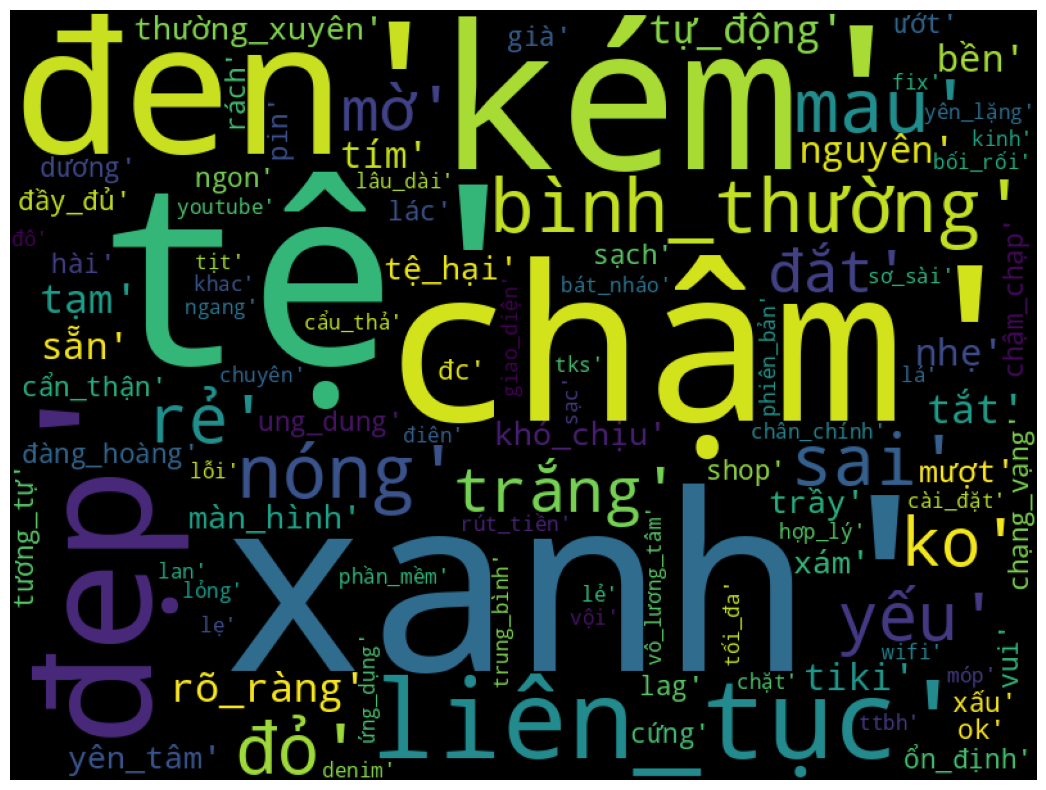

In [32]:
import wordcloud
import matplotlib.pyplot as plt
%matplotlib inline
cloud = np.array(pos_negative_A).flatten()
plt.figure(figsize=(20,10))
word_cloud = wordcloud.WordCloud(max_words=100,background_color ="black",
                               width=800,height=600,mode="RGB").generate(str(cloud))
plt.axis("off")
plt.imshow(word_cloud)

In [33]:
pos_negative_N = []
for i in range(len(pos_negative)):
  j = pos_negative[i]
  l = j[1]
  n = j[0]
  for k in range(len(l)):
    if l[k] == 'N':
      pos_negative_N.append(n[k])
print(pos_negative_N)

['dòng', 'sạc', 'hộp', 'máy', 'hàng', 'mẫu_mã', 'thời_buổi', 'chuyển_khoản', 'máy', 'lag', 'tiki', 'lừa_đảo', 'hàng', 'âhhhaba', 'dsnsnsnd', 'tiki', 'khách_hàng', 'astra', 'đc', 'điện_thoại', 'hàng', 'đính', 'hàng', 'hãng', 'anh_em', 'tiki', 'hàng', 'giở_trò', 'tiki', 'tiki', 'lừa_đảo', 'anh_chị_em', 'tiki', 'điện_thoại', 'tầm', 'lỗi', 'máy', 'bộ_nhớ', 'khả_dụng', 'micro', 'sd', 'type', 'lỗi', 'kĩ', 'redmi', 'tiền', 'màu', 'màu', 'màu', 'lazada', 'tiki', 'haiz', 'điện_thoại_tắt', 'lỗi', 'hàng', 'tiền', 'máy', 'lag', 'nguyên_nhân', 'loa', 'ko', 'máy', 'loa', 'bình', 'khách_hàng', 'tiki', 'máy', 'chất_lượng', 'nhu_cầu', 'tiền', 'hàng', 'hàng', 'hàng', 'điện_tử', 'ảnh_hưởng', 'chất_lượng', 'sản_phẩm', 'thời_hạn', 'shop', 'sản_phẩm', 'chớp', 'khó_chịu', 'tiki', 'tiki', 'tính_năng', 'mặc_định', 'phản_hồi', 'sản_phẩm', 'sản_phẩm', 'chế_độ', 'option', 'mặc_định', 'sản_phẩm', 'tiki', 'dt', 'xạc', 'pin', 'chất_lượng', 'máy', 'pin', 'tiếng', 'dòng', 'pin', 'máy', 'lỗi', 'cuộc_gọi', 'loa', 'máy',

In [34]:
pos_negative_N_count = {}
for i in pos_negative_N:
  if i not in pos_negative_N_count.keys():
    pos_negative_N_count[i] = 1
  else:
    pos_negative_N_count[i] += 1
pos_negative_N_count

{'dòng': 6,
 'sạc': 21,
 'hộp': 24,
 'máy': 184,
 'hàng': 195,
 'mẫu_mã': 3,
 'thời_buổi': 1,
 'chuyển_khoản': 1,
 'lag': 10,
 'tiki': 92,
 'lừa_đảo': 2,
 'âhhhaba': 1,
 'dsnsnsnd': 1,
 'khách_hàng': 22,
 'astra': 2,
 'đc': 19,
 'điện_thoại': 76,
 'đính': 1,
 'hãng': 5,
 'anh_em': 2,
 'giở_trò': 1,
 'anh_chị_em': 1,
 'tầm': 16,
 'lỗi': 38,
 'bộ_nhớ': 2,
 'khả_dụng': 1,
 'micro': 2,
 'sd': 2,
 'type': 1,
 'kĩ': 3,
 'redmi': 1,
 'tiền': 37,
 'màu': 56,
 'lazada': 1,
 'haiz': 1,
 'điện_thoại_tắt': 1,
 'nguyên_nhân': 1,
 'loa': 21,
 'ko': 50,
 'bình': 1,
 'chất_lượng': 23,
 'nhu_cầu': 2,
 'điện_tử': 14,
 'ảnh_hưởng': 1,
 'sản_phẩm': 76,
 'thời_hạn': 2,
 'shop': 57,
 'chớp': 1,
 'khó_chịu': 2,
 'tính_năng': 1,
 'mặc_định': 2,
 'phản_hồi': 6,
 'chế_độ': 7,
 'option': 1,
 'dt': 6,
 'xạc': 4,
 'pin': 39,
 'tiếng': 17,
 'cuộc_gọi': 3,
 'công_ty': 2,
 'order': 2,
 'thông_tin': 8,
 'phút': 5,
 'khăng_khăng': 1,
 'máy_móc': 1,
 'chương_trình': 2,
 'tệ': 5,
 'nhìu': 3,
 'khoá': 2,
 'acc': 1,
 'tích

In [35]:
count = zip(pos_negative_N_count.keys(), pos_negative_N_count.values())
wc = pd.DataFrame(count, columns=['word', 'count'])
wc['rank'] = wc['count'].rank(method='first', ascending=False)
wc = wc.sort_values(by='rank')
wc.head(10)

,word,count,rank
4,hàng,195,1.0
3,máy,184,2.0
9,tiki,92,3.0
16,điện_thoại,76,4.0
44,sản_phẩm,76,5.0
46,shop,57,6.0
32,màu,56,7.0
38,ko,50,8.0
56,pin,39,9.0
23,lỗi,38,10.0


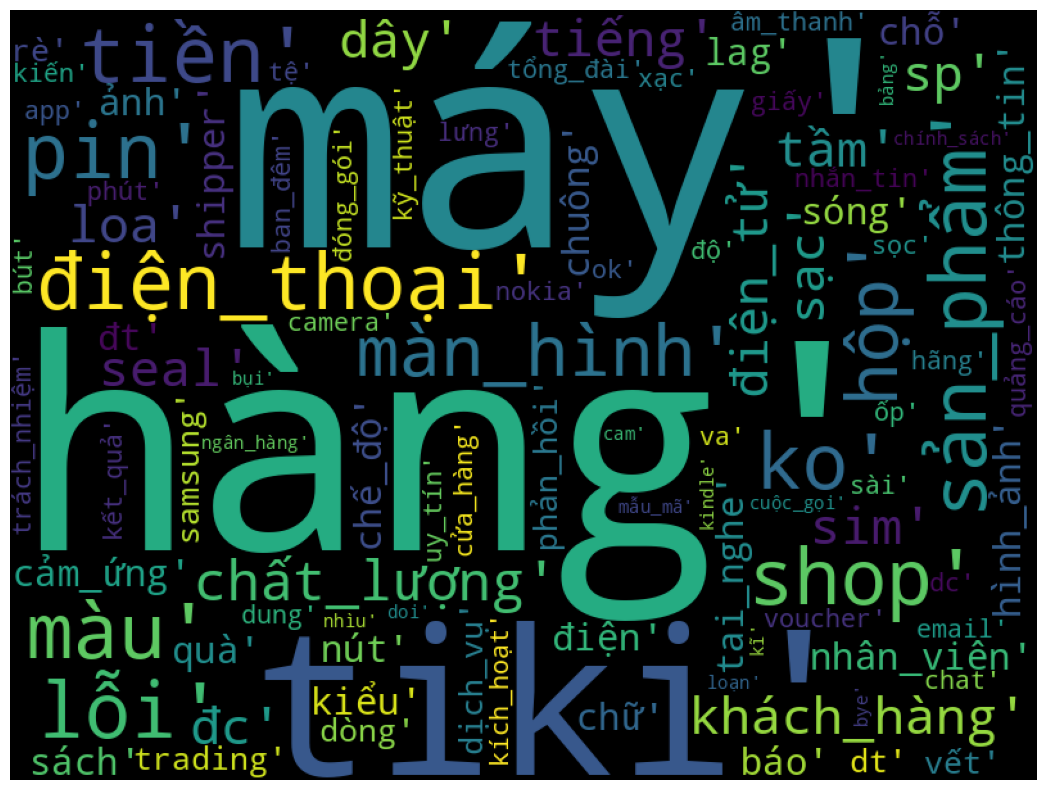

In [36]:
import wordcloud
import matplotlib.pyplot as plt
%matplotlib inline
cloud = np.array(wc['word']).flatten()
plt.figure(figsize=(20,10))
word_cloud = wordcloud.WordCloud(max_words=100,background_color ="black",
                               width=800,height=600,mode="RGB").generate(str(cloud))
plt.axis("off")
plt.imshow(word_cloud)

In [37]:
pos_positive = []
for i in positive:
  pos = ViPosTagger.postagging(str(i))
  pos_positive.append(pos)

In [38]:
pos_positive_A = []
for i in range(len(pos_positive)):
  j = pos_positive[i]
  l = j[1]
  n = j[0]
  for k in range(len(l)):
    if l[k] == 'A':
      pos_positive_A.append(n[k])

In [39]:
pos_positive_N = []
for i in range(len(pos_positive)):
  j = pos_positive[i]
  l = j[1]
  n = j[0]
  for k in range(len(l)):
    if l[k] == 'N':
      pos_positive_N.append(n[k])

In [40]:
pos_positive_A_count = {}
for i in pos_positive_A:
  if i not in pos_positive_A_count.keys():
    pos_positive_A_count[i] = 1
  else:
    pos_positive_A_count[i] += 1

In [41]:
pos_positive_N_count = {}
for i in pos_positive_N:
  if i not in pos_positive_N_count.keys():
    pos_positive_N_count[i] = 1
  else:
    pos_positive_N_count[i] += 1

In [42]:
count = zip(pos_positive_N_count.keys(), pos_positive_N_count.values())
wc1 = pd.DataFrame(count, columns=['word', 'count'])
wc1['rank'] = wc1['count'].rank(method='first', ascending=False)
wc1 = wc1.sort_values(by='rank')
wc1.head(10)

,word,count,rank
1,hàng,1409,1.0
15,máy,858,2.0
20,sản_phẩm,456,3.0
29,shop,452,4.0
4,hãng,297,5.0
19,seal,293,6.0
24,tiki,251,7.0
77,chất_lượng,236,8.0
26,ok,224,9.0
0,điện_thoại,220,10.0


In [43]:
count = zip(pos_positive_A_count.keys(), pos_positive_A_count.values())
wc2 = pd.DataFrame(count, columns=['word', 'count'])
wc2['rank'] = wc2['count'].rank(method='first', ascending=False)
wc2 = wc2.sort_values(by='rank')
wc2.head(10)

,word,count,rank
1,đẹp,620,1.0
13,cẩn_thận,229,2.0
0,nguyên,174,3.0
6,rẻ,137,4.0
12,ngon,67,5.0
24,tuyệt_vời,67,6.0
38,nhẹ,66,7.0
23,đầy_đủ,60,8.0
4,mượt,56,9.0
26,kỹ,52,10.0


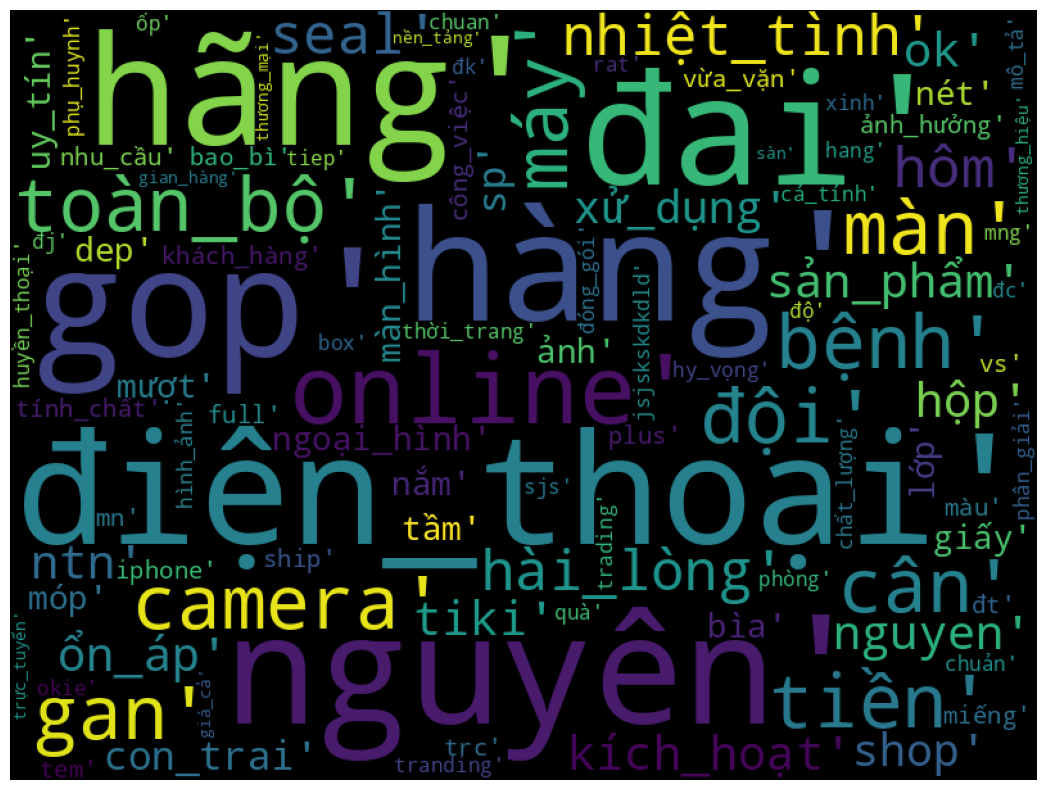

In [44]:
import wordcloud
import matplotlib.pyplot as plt
%matplotlib inline
cloud = np.array(pos_positive_N_count).flatten()
plt.figure(figsize=(20,10))
word_cloud = wordcloud.WordCloud(max_words=100,background_color ="black",
                               width=800,height=600,mode="RGB").generate(str(cloud))
plt.axis("off")
plt.imshow(word_cloud)

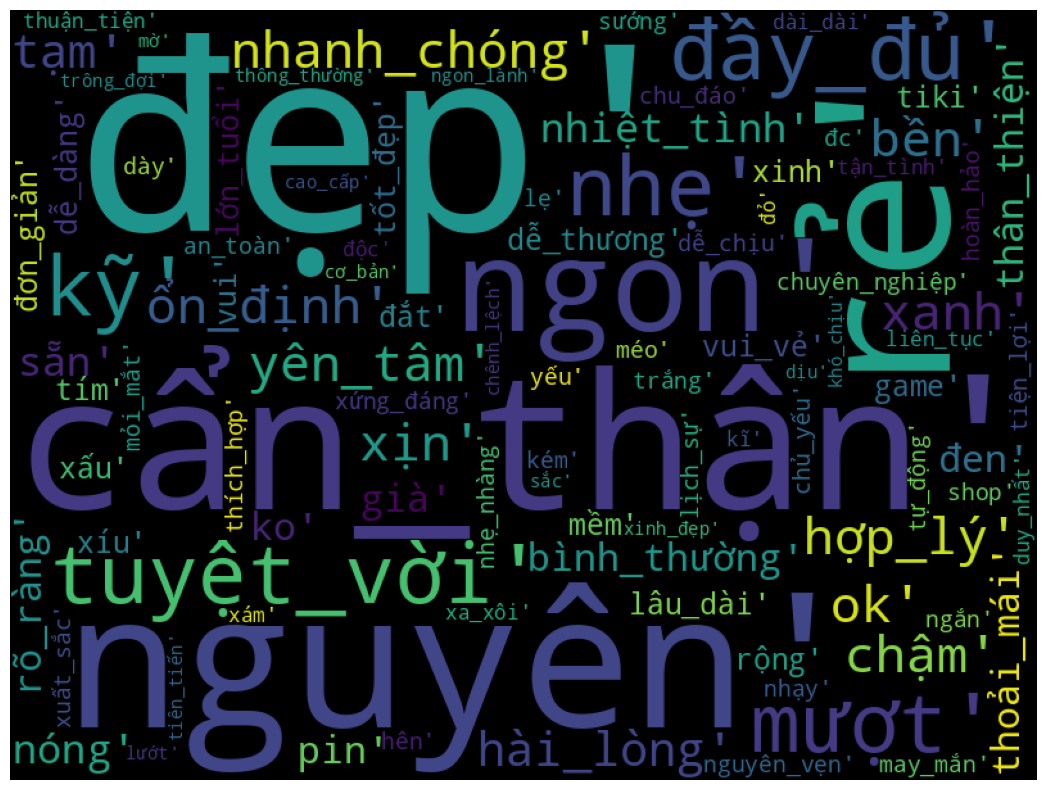

In [45]:
import wordcloud
import matplotlib.pyplot as plt
%matplotlib inline
cloud = np.array(wc2['word']).flatten()
plt.figure(figsize=(20,10))
word_cloud = wordcloud.WordCloud(max_words=100,background_color ="black",
                               width=800,height=600,mode="RGB").generate(str(cloud))
plt.axis("off")
plt.imshow(word_cloud)

In [46]:
pos_neutral = []
for i in neutral:
  pos = ViPosTagger.postagging(str(i))
  pos_neutral.append(pos)

In [47]:
pos_neutral_A = []
for i in range(len(pos_neutral)):
  j = pos_neutral[i]
  l = j[1]
  n = j[0]
  for k in range(len(l)):
    if l[k] == 'A':
      pos_neutral_A.append(n[k])

In [48]:
pos_neutral_N = []
for i in range(len(pos_neutral)):
  j = pos_neutral[i]
  l = j[1]
  n = j[0]
  for k in range(len(l)):
    if l[k] == 'N':
      pos_neutral_N.append(n[k])

In [49]:
pos_neutral_A_count = {}
for i in pos_neutral_A:
  if i not in pos_neutral_A_count.keys():
    pos_neutral_A_count[i] = 1
  else:
    pos_neutral_A_count[i] += 1

In [50]:
pos_neutral_N_count = {}
for i in pos_neutral_N:
  if i not in pos_neutral_N_count.keys():
    pos_neutral_N_count[i] = 1
  else:
    pos_neutral_N_count[i] += 1

In [51]:
count = zip(pos_neutral_N_count.keys(), pos_neutral_N_count.values())
wc3 = pd.DataFrame(count, columns=['word', 'count'])
wc3['rank'] = wc3['count'].rank(method='first', ascending=False)
wc3 = wc3.sort_values(by='rank')
wc3.head(10)

,word,count,rank
0,hàng,151,1.0
14,máy,140,2.0
80,ok,45,3.0
92,sản_phẩm,45,4.0
10,shop,43,5.0
4,điện_thoại,37,6.0
98,màu,32,7.0
32,seal,31,8.0
28,pin,30,9.0
36,tiki,29,10.0


In [52]:
count = zip(pos_neutral_A_count.keys(), pos_neutral_A_count.values())
wc4 = pd.DataFrame(count, columns=['word', 'count'])
wc4['rank'] = wc4['count'].rank(method='first', ascending=False)
wc4 = wc4.sort_values(by='rank')
wc4.head(10)

,word,count,rank
1,đẹp,37,1.0
4,chậm,28,2.0
8,nóng,18,3.0
13,cẩn_thận,18,4.0
3,tạm,17,5.0
14,nguyên,17,6.0
37,xanh,12,7.0
7,nhẹ,11,8.0
12,đầy_đủ,11,9.0
61,đen,11,10.0


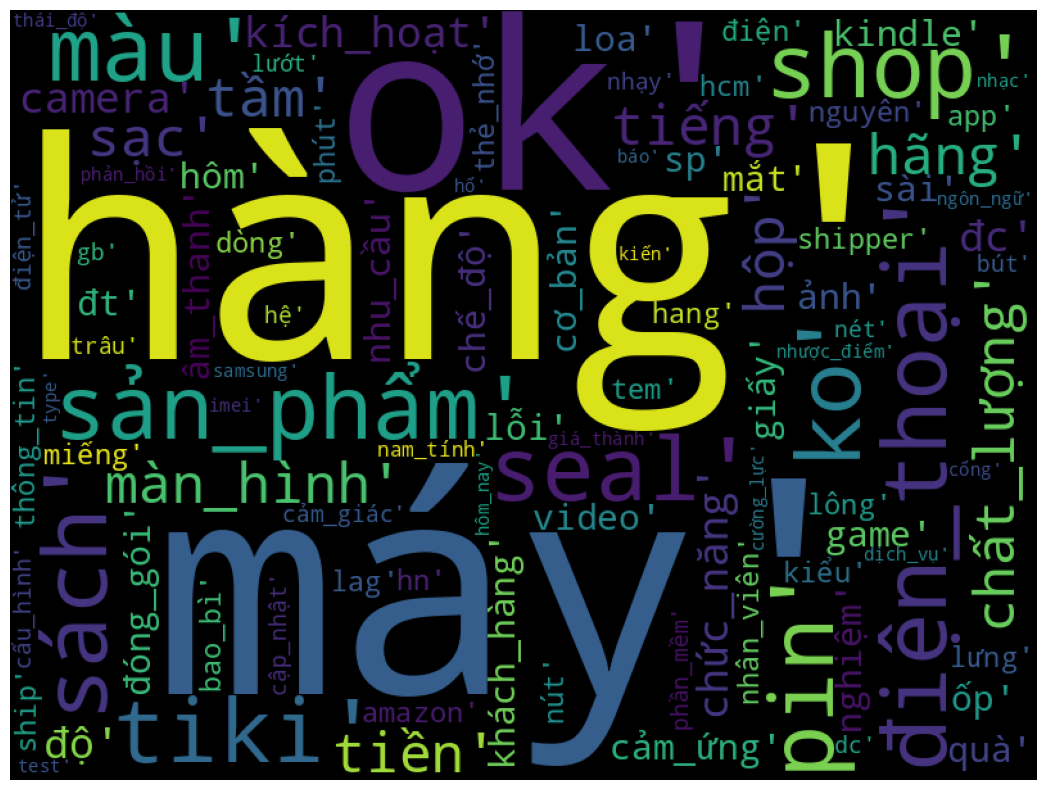

In [53]:
import wordcloud
import matplotlib.pyplot as plt
%matplotlib inline
cloud = np.array(wc3['word']).flatten()
plt.figure(figsize=(20,10))
word_cloud = wordcloud.WordCloud(max_words=100,background_color ="black",
                               width=800,height=600,mode="RGB").generate(str(cloud))
plt.axis("off")
plt.imshow(word_cloud)

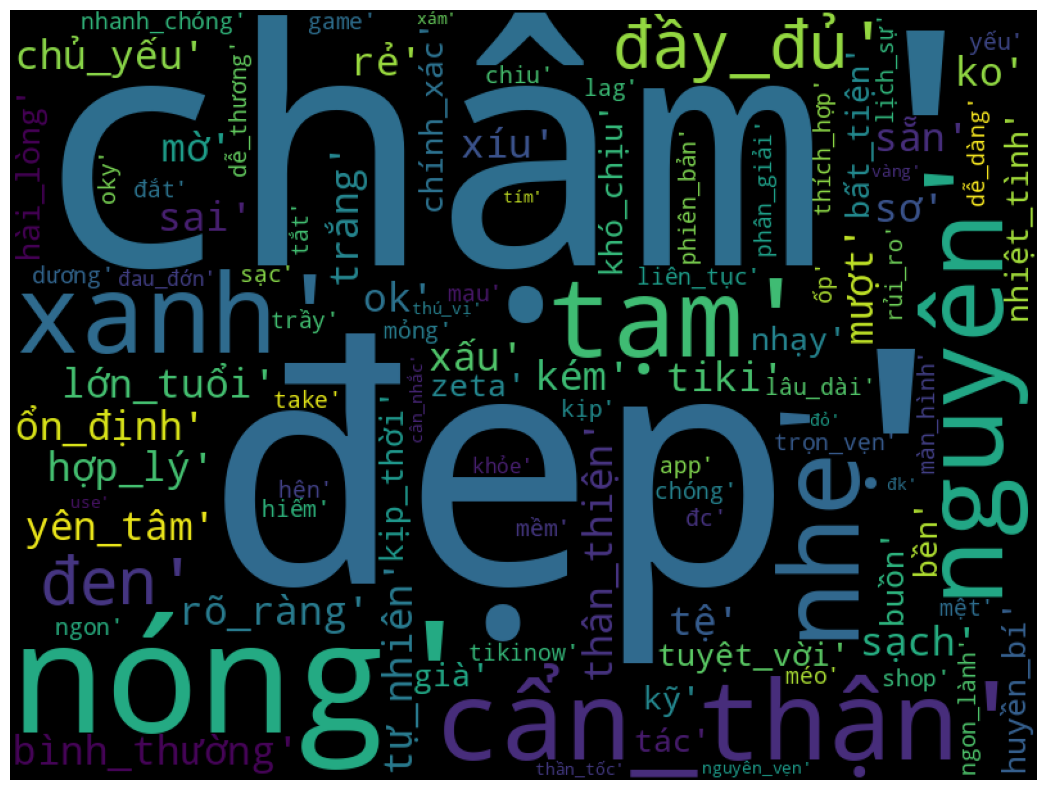

In [54]:
import wordcloud
import matplotlib.pyplot as plt
%matplotlib inline
cloud = np.array(wc4['word']).flatten()
plt.figure(figsize=(20,10))
word_cloud = wordcloud.WordCloud(max_words=100,background_color ="black",
                               width=800,height=600,mode="RGB").generate(str(cloud))
plt.axis("off")
plt.imshow(word_cloud)

# Phân Topic

In [55]:
from nltk import ngrams
from gensim.models import Word2Vec

import sys

pd.options.display.max_rows = 9999

In [56]:
%%timeit
def kieu_ngram(string, n=1):
    gram_str = list(ngrams(string.split(), n))
    return [ " ".join(gram).lower() for gram in gram_str ]

df["1gram"] = df.content_clean.apply(lambda t: kieu_ngram(t, 1))



81.7 ms ± 30 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [57]:
df.head(10)

,id,content,rating,sentiment,content_clean,1gram
0,19531204,"Mình đã nhận được điện thoại, hàng còn nguyên ...",5,positive,điện_thoại hàng nguyên đai nguyên đẹp kiểm_tra...,"[điện_thoại, hàng, nguyên, đai, nguyên, đẹp, k..."
1,19082694,"Camera cũng tạm, đủ sáng thì ok, camera trước ...",5,positive,camera tạm ok camera chụp bệnh gan điện_thoại ...,"[camera, tạm, ok, camera, chụp, bệnh, gan, điệ..."
2,19120490,"Mua lần nào cũng hài lòng , đặt hôm trước thì ...",5,positive,mua hài_lòng hôm hôm giao shiper nhiệt_tình rẻ...,"[mua, hài_lòng, hôm, hôm, giao, shiper, nhiệt_..."
3,19508169,"Đúng nguyen seal, giao hàng nhanh lịch sự, rất...",5,positive,nguyen seal giao hàng lịch_sự hài_lòng,"[nguyen, seal, giao, hàng, lịch_sự, hài_lòng]"
4,19180405,Ủa mà dòng này không có sẵn sạc kèm theo trong...,2,negative,dòng sẵn sạc kèm hộp đựng máy giao hàng trễ,"[dòng, sẵn, sạc, kèm, hộp, đựng, máy, giao, hà..."
5,19211217,Nguyên seal,5,positive,nguyên seal,"[nguyên, seal]"
6,19154234,OK lem,5,positive,ok lem,"[ok, lem]"
7,19279062,"Đóng gói đẹp, Máy nguyên hộp, chưa xử dụng, đú...",5,positive,đóng_gói đẹp máy nguyên hộp xử_dụng shop quảng...,"[đóng_gói, đẹp, máy, nguyên, hộp, xử_dụng, sho..."
8,19313410,"Mua gửi cho con trai ở xa, nên không nhìn được...",5,positive,mua gửi con_trai con_trai khen,"[mua, gửi, con_trai, con_trai, khen]"
9,19508849,"Mẫu mã đẹp nhung sai không ngon, chi nghe gọi ...",1,negative,mẫu_mã đẹp sai ngon gọi ok,"[mẫu_mã, đẹp, sai, ngon, gọi, ok]"


In [58]:
df["row"] = df["1gram"]
df.head(10)

,id,content,rating,sentiment,content_clean,1gram,row
0,19531204,"Mình đã nhận được điện thoại, hàng còn nguyên ...",5,positive,điện_thoại hàng nguyên đai nguyên đẹp kiểm_tra...,"[điện_thoại, hàng, nguyên, đai, nguyên, đẹp, k...","[điện_thoại, hàng, nguyên, đai, nguyên, đẹp, k..."
1,19082694,"Camera cũng tạm, đủ sáng thì ok, camera trước ...",5,positive,camera tạm ok camera chụp bệnh gan điện_thoại ...,"[camera, tạm, ok, camera, chụp, bệnh, gan, điệ...","[camera, tạm, ok, camera, chụp, bệnh, gan, điệ..."
2,19120490,"Mua lần nào cũng hài lòng , đặt hôm trước thì ...",5,positive,mua hài_lòng hôm hôm giao shiper nhiệt_tình rẻ...,"[mua, hài_lòng, hôm, hôm, giao, shiper, nhiệt_...","[mua, hài_lòng, hôm, hôm, giao, shiper, nhiệt_..."
3,19508169,"Đúng nguyen seal, giao hàng nhanh lịch sự, rất...",5,positive,nguyen seal giao hàng lịch_sự hài_lòng,"[nguyen, seal, giao, hàng, lịch_sự, hài_lòng]","[nguyen, seal, giao, hàng, lịch_sự, hài_lòng]"
4,19180405,Ủa mà dòng này không có sẵn sạc kèm theo trong...,2,negative,dòng sẵn sạc kèm hộp đựng máy giao hàng trễ,"[dòng, sẵn, sạc, kèm, hộp, đựng, máy, giao, hà...","[dòng, sẵn, sạc, kèm, hộp, đựng, máy, giao, hà..."
5,19211217,Nguyên seal,5,positive,nguyên seal,"[nguyên, seal]","[nguyên, seal]"
6,19154234,OK lem,5,positive,ok lem,"[ok, lem]","[ok, lem]"
7,19279062,"Đóng gói đẹp, Máy nguyên hộp, chưa xử dụng, đú...",5,positive,đóng_gói đẹp máy nguyên hộp xử_dụng shop quảng...,"[đóng_gói, đẹp, máy, nguyên, hộp, xử_dụng, sho...","[đóng_gói, đẹp, máy, nguyên, hộp, xử_dụng, sho..."
8,19313410,"Mua gửi cho con trai ở xa, nên không nhìn được...",5,positive,mua gửi con_trai con_trai khen,"[mua, gửi, con_trai, con_trai, khen]","[mua, gửi, con_trai, con_trai, khen]"
9,19508849,"Mẫu mã đẹp nhung sai không ngon, chi nghe gọi ...",1,negative,mẫu_mã đẹp sai ngon gọi ok,"[mẫu_mã, đẹp, sai, ngon, gọi, ok]","[mẫu_mã, đẹp, sai, ngon, gọi, ok]"


In [59]:
train_data = df.row.tolist()
len(train_data)

3388

In [60]:
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)
model1 = Word2Vec(train_data, vector_size = 100, window = 5, min_count = 1, workers = 4, sg = 1)

In [61]:
len(model1.wv.key_to_index)

3448

In [62]:
model1.wv.key_to_index

{'hàng': 0,
 'máy': 1,
 'giao': 2,
 'mua': 3,
 'đẹp': 4,
 'shop': 5,
 'sản_phẩm': 6,
 'tiki': 7,
 'ok': 8,
 'nguyên': 9,
 'điện_thoại': 10,
 'pin': 11,
 'đóng_gói': 12,
 'seal': 13,
 'ko': 14,
 'hãng': 15,
 'chất_lượng': 16,
 'màn_hình': 17,
 'đọc': 18,
 'cẩn_thận': 19,
 'màu': 20,
 'xài': 21,
 'hài_lòng': 22,
 'sách': 23,
 'bảo_hành': 24,
 'hộp': 25,
 'lắm': 26,
 'sạc': 27,
 'tầm': 28,
 'rẻ': 29,
 'tiền': 30,
 'gọi': 31,
 'sp': 32,
 'đc': 33,
 'nhiệt_tình': 34,
 'mượt': 35,
 'tặng': 36,
 'kèm': 37,
 'kích_hoạt': 38,
 'đt': 39,
 'lỗi': 40,
 'kindle': 41,
 'ủng_hộ': 42,
 'tuyệt_vời': 43,
 'cầm': 44,
 'chụp': 45,
 'tiếng': 46,
 'chậm': 47,
 'loa': 48,
 'nhẹ': 49,
 'mô_tả': 50,
 'vận_chuyển': 51,
 'gói': 52,
 'camera': 53,
 'siêu': 54,
 'chạy': 55,
 'đầy_đủ': 56,
 'ngon': 57,
 'xanh': 58,
 'trâu': 59,
 'tư_vấn': 60,
 'ốp': 61,
 'gửi': 62,
 'nét': 63,
 'trải': 64,
 'nghiệm': 65,
 'quảng_cáo': 66,
 'bền': 67,
 'game': 68,
 'kỹ': 69,
 'điện_tử': 70,
 'giấy': 71,
 'nhân_viên': 72,
 'dc': 73,


In [63]:
model1.wv.similar_by_word("đóng_gói")

[('hàng', 0.9927296042442322),
 ('cẩn_thận', 0.9893547892570496),
 ('giao', 0.9890996813774109),
 ('nguyên', 0.9857803583145142),
 ('hãng', 0.9849644899368286),
 ('gói', 0.982751190662384),
 ('seal', 0.9822611212730408),
 ('sản_phẩm', 0.981741726398468),
 ('hộp', 0.9751777648925781),
 ('kỹ', 0.9717966318130493)]

In [64]:
model1.wv.similar_by_word("vận_chuyển")

[('móp', 0.995169997215271),
 ('yên_tâm', 0.9940292239189148),
 ('shipper', 0.9937350749969482),
 ('dự_kiến', 0.9932039380073547),
 ('điện_tử', 0.9930623173713684),
 ('tem', 0.9928169250488281),
 ('nhanh_chóng', 0.9924404621124268),
 ('nhân_viên', 0.9924370646476746),
 ('hài_lòng', 0.992200493812561),
 ('sp', 0.9916836619377136)]

In [65]:
model1.wv.similar_by_word("giao")

[('hàng', 0.9922569990158081),
 ('cẩn_thận', 0.990993082523346),
 ('hãng', 0.9891856908798218),
 ('đóng_gói', 0.9890997409820557),
 ('sản_phẩm', 0.9871619939804077),
 ('nguyên', 0.9834065437316895),
 ('shop', 0.9823654890060425),
 ('gói', 0.9818066358566284),
 ('seal', 0.9804964065551758),
 ('hộp', 0.9780475497245789)]

In [66]:
model1.wv.similar_by_word("hộp")

[('kỹ', 0.9952467083930969),
 ('gói', 0.9924724698066711),
 ('tem', 0.9905941486358643),
 ('sản_phẩm', 0.9902535676956177),
 ('mô_tả', 0.9900940656661987),
 ('hãng', 0.9889497756958008),
 ('nhanh_chóng', 0.9888610243797302),
 ('chất_lượng', 0.9852254390716553),
 ('hàng', 0.9847456216812134),
 ('ủng_hộ', 0.9845341444015503)]

In [67]:
model1.wv.similar_by_word("điện_thoại")

[('đóng', 0.9969972968101501),
 ('khui', 0.9968180060386658),
 ('quảng_cáo', 0.9967595338821411),
 ('full', 0.9965757727622986),
 ('đt', 0.9964213371276855),
 ('dc', 0.996366560459137),
 ('hi_vọng', 0.9963381290435791),
 ('phục_vụ', 0.9962758421897888),
 ('giá_cả', 0.9962698221206665),
 ('niêm_phong', 0.9961681962013245)]

In [68]:
model1.wv.similar_by_word("máy")

[('active', 0.99234539270401),
 ('box', 0.9916810393333435),
 ('rẻ', 0.9916384816169739),
 ('kĩ', 0.9913321733474731),
 ('vn', 0.990968644618988),
 ('dịch_vụ', 0.9908786416053772),
 ('ok', 0.9906548857688904),
 ('phụ_kiện', 0.9903786778450012),
 ('đai', 0.9903218150138855),
 ('điện_thoại', 0.9902814626693726)]

In [69]:
model1.wv.similar_by_word("chất_lượng")

[('nhanh_chóng', 0.9969789981842041),
 ('mô_tả', 0.9964788556098938),
 ('dự_kiến', 0.9962255358695984),
 ('siêu', 0.9956356287002563),
 ('hài_lòng', 0.9947856664657593),
 ('nhân_viên', 0.9943991899490356),
 ('ủng_hộ', 0.9940168261528015),
 ('kỹ', 0.9915909767150879),
 ('sản_phẩm', 0.991561233997345),
 ('yên_tâm', 0.9915140867233276)]

In [70]:
model1.wv.similar_by_word("sản_phẩm")

[('gói', 0.9953193068504333),
 ('kỹ', 0.993592381477356),
 ('ủng_hộ', 0.9925686120986938),
 ('mô_tả', 0.9925670027732849),
 ('hãng', 0.9924970865249634),
 ('hàng', 0.9917892813682556),
 ('chất_lượng', 0.9915612936019897),
 ('shop', 0.9909889698028564),
 ('nhanh_chóng', 0.9908934831619263),
 ('hộp', 0.9902536273002625)]

In [71]:
word_sanpham = ['máy', 'chất_lượng', 'sản_phẩm', 'điện_thoại']
word_giaohang = ['giao', 'vận_chuyển', 'đóng_gói', 'hộp']

In [72]:
sanpham = []
giaohang = []
for i in range(len(df['row'])):
  if i >= len(df['row']):
        continue
  j = df['row'][i]
  for k in j:
    score1 = 0
    score2 = 0
    for l in word_sanpham:
      score_sanpham = model1.wv.similarity(k, l)
      score1 = score1 + score_sanpham
    for n in word_giaohang:
      score_giaohang = model1.wv.similarity(k, n)
      score2 = score2 + score_giaohang
  if score1 > score2:
    sanpham.append(df['content_clean'][i])
  else:
    giaohang.append(df['content_clean'][i])

In [73]:
sanphamrating = []
giaohangrating = []
dem1 = 0
dem2 = 0
for i in range(len(df['row'])):
  j = df['row'][i]
  for k in j:
    score1 = 0
    score2 = 0
    for l in word_sanpham:
      score_sanpham = model1.wv.similarity(k, l)
      score1 = score1 + score_sanpham
    for n in word_giaohang:
      score_giaohang = model1.wv.similarity(k, n)
      score2 = score2 + score_giaohang
  if score1 > score2:
    sanphamrating.append(df['rating'][i])
    dem1 = dem1 + 1
  else:
    giaohangrating.append(df['rating'][i])
    dem2 = dem2 + 1

In [74]:
ratingsanpham = 0
ratinggiaohang = 0
for i in sanphamrating:
  ratingsanpham = ratingsanpham + i
for i in giaohangrating:
  ratinggiaohang = ratinggiaohang + i

In [75]:
ratingtb_sanpham = ratingsanpham/dem1
ratingtb_giaohang = ratinggiaohang/dem2
print('rating trung bình đánh giá về sản phẩm:', ratingtb_sanpham)
print('rating trung bình đánh giá về giao hàng:', ratingtb_giaohang)

rating trung bình đánh giá về sản phẩm: 4.441799925622908
rating trung bình đánh giá về giao hàng: 4.726752503576538


In [76]:
df_sanpham = pd.DataFrame(sanpham, columns = ['content'])
df_giaohang = pd.DataFrame(giaohang, columns = ['content'])

In [77]:
df_sanpham

,content
0,điện_thoại hàng nguyên đai nguyên đẹp kiểm_tra...
1,camera tạm ok camera chụp bệnh gan điện_thoại ...
2,mua hài_lòng hôm hôm giao shiper nhiệt_tình rẻ...
3,nguyen seal giao hàng lịch_sự hài_lòng
4,dòng sẵn sạc kèm hộp đựng máy giao hàng trễ
5,ok lem
6,đóng_gói đẹp máy nguyên hộp xử_dụng shop quảng...
7,mua gửi con_trai con_trai khen
8,mẫu_mã đẹp sai ngon gọi ok
9,sp


In [78]:
df_giaohang

,content
0,nguyên seal
1,hàng hãng
2,giao đóng_gói cẩn_thận
3,giao hàng sản_phẩm
4,sản_phẩm hãng
5,đóng_gói cẩn_thận lót lớp chống sốc giấy dày v...
6,đc bao_bì hãng full box nguyên seal
7,điện_thoại nguyên seal giao hàng tiki chăm_sóc...
8,hãng nguyên tem nguyên seal giao hàng
9,máy hãng nguyên seal


In [79]:
pos_sanpham = []
for i in sanpham:
  pos = ViPosTagger.postagging(str(i))
  pos_sanpham.append(pos)

In [80]:
pos_sanpham_A = []
for i in range(len(pos_sanpham)):
  j = pos_sanpham[i]
  l = j[1]
  n = j[0]
  for k in range(len(l)):
    if l[k] == 'A':
      pos_sanpham_A.append(n[k])

In [81]:
pos_sanpham_A_count = {}
for i in pos_sanpham_A:
  if i not in pos_sanpham_A_count.keys():
    pos_sanpham_A_count[i] = 1
  else:
    pos_sanpham_A_count[i] += 1

In [82]:
count = zip(pos_sanpham_A_count.keys(), pos_sanpham_A_count.values())
wc5 = pd.DataFrame(count, columns=['word', 'count'])
wc5['rank'] = wc5['count'].rank(method='first', ascending=False)
wc5 = wc5.sort_values(by='rank')
wc5.head(10)

,word,count,rank
1,đẹp,543,1.0
19,cẩn_thận,143,2.0
0,nguyên,135,3.0
6,rẻ,129,4.0
29,chậm,74,5.0
34,nhẹ,70,6.0
25,đầy_đủ,66,7.0
4,mượt,63,8.0
12,ngon,63,9.0
26,tuyệt_vời,63,10.0


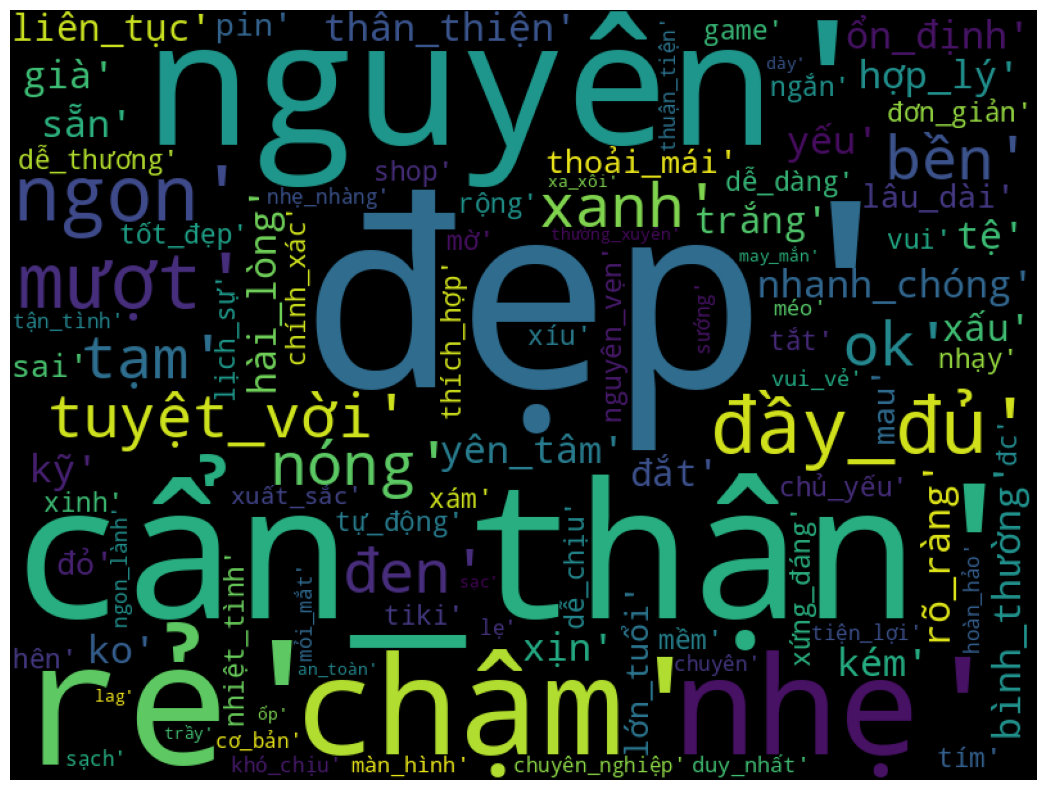

In [83]:
import wordcloud
import matplotlib.pyplot as plt
%matplotlib inline
cloud = np.array(wc5['word']).flatten()
plt.figure(figsize=(20,10))
word_cloud = wordcloud.WordCloud(max_words=100,background_color ="black",
                               width=800,height=600,mode="RGB").generate(str(cloud))
plt.axis("off")
plt.imshow(word_cloud)

In [84]:
pos_giaohang = []
for i in giaohang:
  pos = ViPosTagger.postagging(str(i))
  pos_giaohang.append(pos)

In [85]:
pos_giaohang_A = []
for i in range(len(pos_giaohang)):
  j = pos_giaohang[i]
  l = j[1]
  n = j[0]
  for k in range(len(l)):
    if l[k] == 'A':
      pos_giaohang_A.append(n[k])

In [86]:
pos_giaohang_A_count = {}
for i in pos_giaohang_A:
  if i not in pos_giaohang_A_count.keys():
    pos_giaohang_A_count[i] = 1
  else:
    pos_giaohang_A_count[i] += 1

In [87]:
count = zip(pos_giaohang_A_count.keys(), pos_giaohang_A_count.values())
wc6 = pd.DataFrame(count, columns=['word', 'count'])
wc6['rank'] = wc6['count'].rank(method='first', ascending=False)
wc6 = wc6.sort_values(by='rank')
wc6.head(10)

,word,count,rank
3,đẹp,125,1.0
0,cẩn_thận,106,2.0
2,nguyên,60,3.0
18,rẻ,24,4.0
7,kỹ,20,5.0
13,nhiệt_tình,19,6.0
45,nhanh_chóng,12,7.0
21,nhẹ,11,8.0
4,yên_tâm,10,9.0
6,ngon,8,10.0


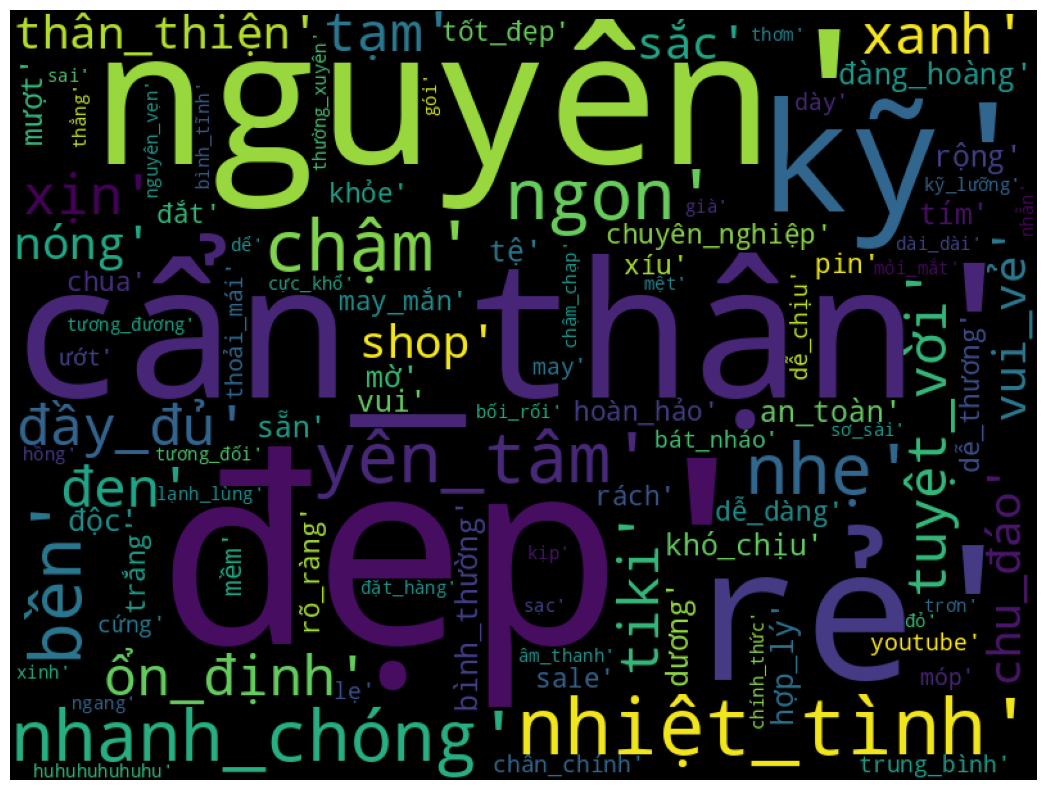

In [88]:
import wordcloud
import matplotlib.pyplot as plt
%matplotlib inline
cloud = np.array(wc6['word']).flatten()
plt.figure(figsize=(20,10))
word_cloud = wordcloud.WordCloud(max_words=100,background_color ="black",
                               width=800,height=600,mode="RGB").generate(str(cloud))
plt.axis("off")
plt.imshow(word_cloud)

# Mô hình

In [89]:
y = df['sentiment']
x = df['content_clean']
import pickle
pickle.dump(X, open('X_data.pkl', 'wb'))
pickle.dump(y, open('y_data.pkl', 'wb'))
pickle.dump(X, open('X_test.pkl', 'wb'))
pickle.dump(y, open('y_test.pkl', 'wb'))

In [90]:
import pickle

X_data = pickle.load(open('X_data.pkl', 'rb'))
y_data = pickle.load(open('y_data.pkl', 'rb'))
X_test = pickle.load(open('X_test.pkl', 'rb'))
y_test = pickle.load(open('y_test.pkl', 'rb'))


In [91]:
from sklearn.feature_extraction.text import TfidfVectorizer
tf = TfidfVectorizer(min_df=5,max_df= 0.8,max_features=3000,sublinear_tf=True)
tf.fit(x)
X_data = tf.transform(x)
print(X_data)

  (0, 748)	0.2886235938084245
  (0, 747)	0.12167897480931643
  (0, 723)	0.15048984939524693
  (0, 715)	0.2950567302578929
  (0, 595)	0.18789189434371875
  (0, 553)	0.4837698176797237
  (0, 449)	0.2589870313925014
  (0, 397)	0.2337903984443458
  (0, 355)	0.2041862067540018
  (0, 283)	0.4241894006553221
  (0, 231)	0.15262082964009355
  (0, 229)	0.14566948972322571
  (0, 187)	0.26749445577010916
  (0, 32)	0.2518362357800361
  (1, 747)	0.15058183095656813
  (1, 723)	0.18623625895785748
  (1, 667)	0.3695957132596672
  (1, 637)	0.291323963384209
  (1, 562)	0.34117661625179047
  (1, 477)	0.19033274591358595
  (1, 445)	0.16589738757061032
  (1, 373)	0.2410327936379731
  (1, 363)	0.1317335698383067
  (1, 357)	0.3287623246884022
  (1, 121)	0.2640519927066986
  :	:
  (3379, 224)	0.5569557684416323
  (3379, 2)	0.5322619674274344
  (3380, 445)	0.5509532614612684
  (3380, 360)	0.7559239851032081
  (3380, 229)	0.3535950118863043
  (3381, 371)	0.5533899609243401
  (3381, 363)	0.2731303798395947
  (338

In [92]:
MODEL_PATH = "models"
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
import os
if not os.path.exists(MODEL_PATH):
    os.makedirs(MODEL_PATH)
import time
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

In [93]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size = 0.2, random_state = 42)

label_encoder = LabelEncoder()
label_encoder.fit(y_train)
print(list(label_encoder.classes_), '\n')
y_train = label_encoder.transform(y_train)
y_test = label_encoder.transform(y_test)

print(X_train[0], y_train[0], '\n')
print(X_test[0], y_test[0])

['negative', 'neutral', 'positive'] 

 2 

  (0, 747)	0.2616045828919949
  (0, 696)	0.36591981521441796
  (0, 540)	0.5535343727959976
  (0, 537)	0.2814197839759644
  (0, 433)	0.48654038406227307
  (0, 373)	0.4187443003076586 2


In [94]:
model = SVC()
model.fit(X_train,y_train)
pickle.dump(model, open(os.path.join(MODEL_PATH, "svm.pkl"), 'wb'))
model3 = pickle.load(open(os.path.join(MODEL_PATH,"svm.pkl"), 'rb'))
y_pred = model3.predict(X_test)

In [95]:
model = pickle.load(open(os.path.join(MODEL_PATH,"svm.pkl"), 'rb'))
y_pred = model.predict(X_test)
print('SVM, Accuracy =', np.mean(y_pred == y_test))


SVM, Accuracy = 0.8067846607669616


In [96]:
from sklearn.metrics import classification_report

nb_model = pickle.load(open(os.path.join(MODEL_PATH,"svm.pkl"), 'rb'))
y_pred = nb_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=list(label_encoder.classes_)))

              precision    recall  f1-score   support

    negative       0.69      0.35      0.47        82
     neutral       0.50      0.01      0.03        71
    positive       0.82      0.98      0.89       525

    accuracy                           0.81       678
   macro avg       0.67      0.45      0.46       678
weighted avg       0.77      0.81      0.75       678



# Dự Đoán

In [97]:
text =[["cực kỳ tức giận với thái độ của shipper giao hàng, không thèm gọi trước đã báo trên tiki rằng mình không nhận điện thoại nên đã hủy đơn của mình"],["dt giao sai so với loại mà mình đã mua"],["gút rất tốt"],["dt giá rẽ tuy nhiên màu giao sai mn ko nên mua ở gian hàng này"],["giao hàng nhanh chóng "],["máy sử dụng nhanh nóng và chậm tuy nhiên dùng vẫn ok"]]
for i in text:
  test = tf.transform(i)
  print(f"Phản hồi của khách hàng: {i} - Dự đoán nhãn: {model.predict(test)}")


Phản hồi của khách hàng: ['cực kỳ tức giận với thái độ của shipper giao hàng, không thèm gọi trước đã báo trên tiki rằng mình không nhận điện thoại nên đã hủy đơn của mình'] - Dự đoán nhãn: [0]
Phản hồi của khách hàng: ['dt giao sai so với loại mà mình đã mua'] - Dự đoán nhãn: [0]
Phản hồi của khách hàng: ['gút rất tốt'] - Dự đoán nhãn: [2]
Phản hồi của khách hàng: ['dt giá rẽ tuy nhiên màu giao sai mn ko nên mua ở gian hàng này'] - Dự đoán nhãn: [0]
Phản hồi của khách hàng: ['giao hàng nhanh chóng '] - Dự đoán nhãn: [2]
Phản hồi của khách hàng: ['máy sử dụng nhanh nóng và chậm tuy nhiên dùng vẫn ok'] - Dự đoán nhãn: [1]


In [98]:
text =[["dt quá xấu ko giống như quảng cáo j cả"],["lừa đảo mọi người nên tránh xa kênh bán này"],["đầy đủ phụ kiện, hàng nhận được cùng giống như ảnh"],["hàng giao tới bị móp méo, cũng may điện thoại vẫn bình thường"],["mua ngay chúng dịp sale nên mua đc giá rất hời !!"],["máy giật lag kinh ngủng, mới mua mà đã vậy r yêu cầu hoàn tiền lại cho tôi"]]
for i in text:
  test = tf.transform(i)
  print(f"Phản hồi của khách hàng: {i} - Dự đoán nhãn: {model.predict(test)}")

Phản hồi của khách hàng: ['dt quá xấu ko giống như quảng cáo j cả'] - Dự đoán nhãn: [2]
Phản hồi của khách hàng: ['lừa đảo mọi người nên tránh xa kênh bán này'] - Dự đoán nhãn: [2]
Phản hồi của khách hàng: ['đầy đủ phụ kiện, hàng nhận được cùng giống như ảnh'] - Dự đoán nhãn: [2]
Phản hồi của khách hàng: ['hàng giao tới bị móp méo, cũng may điện thoại vẫn bình thường'] - Dự đoán nhãn: [2]
Phản hồi của khách hàng: ['mua ngay chúng dịp sale nên mua đc giá rất hời !!'] - Dự đoán nhãn: [2]
Phản hồi của khách hàng: ['máy giật lag kinh ngủng, mới mua mà đã vậy r yêu cầu hoàn tiền lại cho tôi'] - Dự đoán nhãn: [0]
